In [7]:
import pandas as pd
import numpy as np
import re

In [8]:
train_df = pd.read_csv("../data/train_dataset.csv")
val_df = pd.read_csv("../data/val_dataset.csv")
test_df = pd.read_csv("../data/test_dataset.csv")

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 41999  Val: 6000  Test: 12000


In [9]:
def engineer_features(df):
    text = df["text"].fillna("")

    feats = pd.DataFrame(index=df.index)

    char_count = text.str.len().replace(0, 1)
    word_count = text.str.split().str.len().replace(0, 1)

    feats["pct_uppercase"] = text.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    feats["pct_digits"] = text.apply(lambda x: sum(1 for c in x if c.isdigit()) / max(len(x), 1))
    feats["pct_punctuation"] = text.apply(lambda x: sum(1 for c in x if c in "!?.,;:'-\"()") / max(len(x), 1))
    feats["pct_exclamation"] = text.str.count("!") / char_count
    feats["pct_question"] = text.str.count(r"\?") / char_count
    feats["pct_spaces"] = text.str.count(" ") / char_count

    feats["has_exclamation"] = (text.str.contains("!", regex=False)).astype(int)
    feats["has_question"] = (text.str.contains("?", regex=False)).astype(int)
    feats["has_ellipsis"] = (text.str.contains("...", regex=False)).astype(int)
    feats["has_all_caps_word"] = text.apply(lambda x: int(any(w.isupper() and len(w) > 1 for w in x.split())))
    feats["has_negation"] = (text.str.lower().str.contains(r"\b(not|no|never|neither|nobody|nothing|nowhere|nor|cannot|can\'t|won\'t|don\'t|doesn\'t|isn\'t|aren\'t|wasn\'t|weren\'t)\b")).astype(int)

    return feats

train_feats = engineer_features(train_df)
val_feats = engineer_features(val_df)
test_feats = engineer_features(test_df)

feature_names_eng = list(train_feats.columns)
print(f"Engineered features ({len(feature_names_eng)}): {feature_names_eng}")
train_feats.describe().round(4)

/var/folders/rl/kj3ltxg12ls9b71lkvtbygnm0000gn/T/ipykernel_35094/2502430977.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  feats["has_negation"] = (text.str.lower().str.contains(r"\b(not|no|never|neither|nobody|nothing|nowhere|nor|cannot|can\'t|won\'t|don\'t|doesn\'t|isn\'t|aren\'t|wasn\'t|weren\'t)\b")).astype(int)
/var/folders/rl/kj3ltxg12ls9b71lkvtbygnm0000gn/T/ipykernel_35094/2502430977.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  feats["has_negation"] = (text.str.lower().str.contains(r"\b(not|no|never|neither|nobody|nothing|nowhere|nor|cannot|can\'t|won\'t|don\'t|doesn\'t|isn\'t|aren\'t|wasn\'t|weren\'t)\b")).astype(int)


Engineered features (11): ['pct_uppercase', 'pct_digits', 'pct_punctuation', 'pct_exclamation', 'pct_question', 'pct_spaces', 'has_exclamation', 'has_question', 'has_ellipsis', 'has_all_caps_word', 'has_negation']


/var/folders/rl/kj3ltxg12ls9b71lkvtbygnm0000gn/T/ipykernel_35094/2502430977.py:27: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  feats["has_negation"] = (text.str.lower().str.contains(r"\b(not|no|never|neither|nobody|nothing|nowhere|nor|cannot|can\'t|won\'t|don\'t|doesn\'t|isn\'t|aren\'t|wasn\'t|weren\'t)\b")).astype(int)


,pct_uppercase,pct_digits,pct_punctuation,pct_exclamation,pct_question,pct_spaces,has_exclamation,has_question,has_ellipsis,has_all_caps_word,has_negation
count,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000,41999.0000
mean,0.0558,0.0081,0.0380,0.0046,0.0010,0.1723,0.2768,0.1175,0.1668,0.3292,0.4384
std,0.0922,0.0245,0.0469,0.0234,0.0081,0.0477,0.4474,0.3220,0.3728,0.4699,0.4962
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.0207,0.0000,0.0206,0.0000,0.0000,0.1613,0.0000,0.0000,0.0000,0.0000,0.0000
50%,0.0314,0.0000,0.0303,0.0000,0.0000,0.1786,0.0000,0.0000,0.0000,0.0000,0.0000
75%,0.0563,0.0069,0.0433,0.0011,0.0000,0.1909,1.0000,0.0000,0.0000,1.0000,1.0000
max,1.0000,1.0000,1.0000,1.0000,0.9420,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import StandardScaler

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 3),
    sublinear_tf=True,
    max_features=200000,
)

X_train_tfidf = vectorizer.fit_transform(train_df["text"])
X_val_tfidf = vectorizer.transform(val_df["text"])
X_test_tfidf = vectorizer.transform(test_df["text"])

tfidf_feature_names = vectorizer.get_feature_names_out()
print(f"TF-IDF features: {len(tfidf_feature_names):,}")

scaler = StandardScaler()
train_feats_scaled = scaler.fit_transform(train_feats)
val_feats_scaled = scaler.transform(val_feats)
test_feats_scaled = scaler.transform(test_feats)

X_train = hstack([X_train_tfidf, train_feats_scaled])
X_val = hstack([X_val_tfidf, val_feats_scaled])
X_test = hstack([X_test_tfidf, test_feats_scaled])

y_train = train_df["sentiment"]
y_val = val_df["sentiment"]
y_test = test_df["sentiment"]

all_feature_names = list(tfidf_feature_names) + feature_names_eng
print(f"Total features: {len(all_feature_names):,}")
print(f"X_train: {X_train.shape}")

TF-IDF features: 200,000
Total features: 200,011
X_train: (41999, 200011)


In [11]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

model = SGDClassifier(
    loss="log_loss",
    penalty="l1",
    alpha=1e-5,
    random_state=42,
    warm_start=True,
    max_iter=1,
    tol=None,
)

classes = np.array(["negative", "neutral", "positive"])

max_epochs = 100
patience = 5
best_val_acc = 0
best_epoch = 0
no_improve = 0

history = {"epoch": [], "train_acc": [], "val_acc": [], "val_f1": []}

for epoch in range(1, max_epochs + 1):
    model.partial_fit(X_train, y_train, classes=classes)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    val_acc = accuracy_score(y_val, model.predict(X_val))
    val_f1 = f1_score(y_val, model.predict(X_val), average="macro", zero_division=0)

    history["epoch"].append(epoch)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}  |  train_acc: {train_acc:.4f}  |  val_acc: {val_acc:.4f}  |  val_f1: {val_f1:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        best_coef = model.coef_.copy()
        best_intercept = model.intercept_.copy()
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}. Best val_acc: {best_val_acc:.4f} at epoch {best_epoch}")
        break

model.coef_ = best_coef
model.intercept_ = best_intercept
print(f"\nRestored weights from epoch {best_epoch}")

Epoch   1  |  train_acc: 0.7124  |  val_acc: 0.6882  |  val_f1: 0.6799
Epoch   5  |  train_acc: 0.7930  |  val_acc: 0.7308  |  val_f1: 0.7231
Epoch  10  |  train_acc: 0.8248  |  val_acc: 0.7478  |  val_f1: 0.7415
Epoch  15  |  train_acc: 0.8360  |  val_acc: 0.7500  |  val_f1: 0.7439
Epoch  20  |  train_acc: 0.8439  |  val_acc: 0.7537  |  val_f1: 0.7476
Epoch  25  |  train_acc: 0.8492  |  val_acc: 0.7543  |  val_f1: 0.7481

Early stopping at epoch 26. Best val_acc: 0.7547 at epoch 21

Restored weights from epoch 21


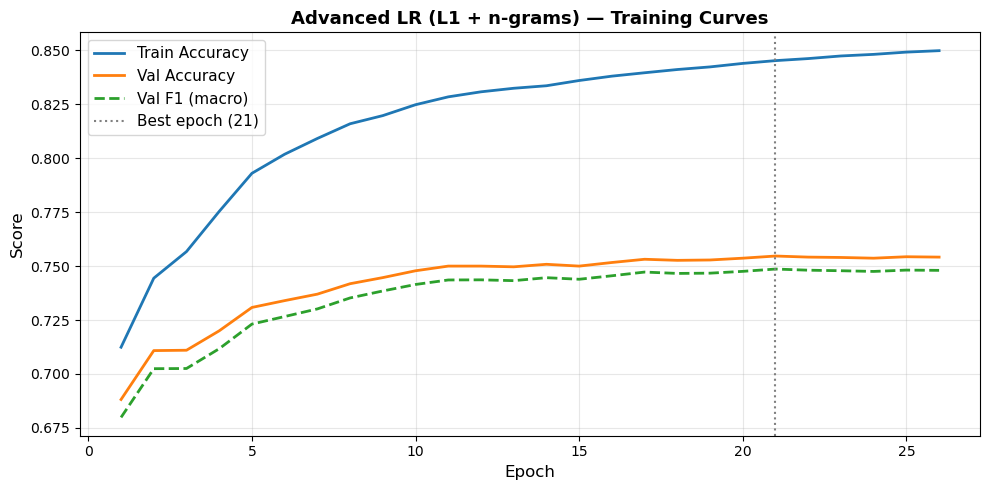

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history["epoch"], history["train_acc"], label="Train Accuracy", linewidth=2)
ax.plot(history["epoch"], history["val_acc"], label="Val Accuracy", linewidth=2)
ax.plot(history["epoch"], history["val_f1"], label="Val F1 (macro)", linewidth=2, linestyle="--")
ax.axvline(x=best_epoch, color="gray", linestyle=":", label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Advanced LR (L1 + n-grams): Training Curves", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
y_pred = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "neutral", "positive"]))

Test Accuracy: 0.7497

              precision    recall  f1-score   support

    negative       0.76      0.78      0.77      4050
     neutral       0.69      0.63      0.66      3451
    positive       0.77      0.81      0.79      4499

    accuracy                           0.75     12000
   macro avg       0.74      0.74      0.74     12000
weighted avg       0.75      0.75      0.75     12000




--- super_short (4000 samples) ---
  Accuracy:  0.748
  F1 (macro): 0.741
  F1 per class: neg=0.739  neu=0.680  pos=0.805

--- short (4001 samples) ---
  Accuracy:  0.739
  F1 (macro): 0.733
  F1 per class: neg=0.765  neu=0.657  pos=0.778

--- medium (2000 samples) ---
  Accuracy:  0.765
  F1 (macro): 0.747
  F1 per class: neg=0.806  neu=0.633  pos=0.802

--- long (1999 samples) ---
  Accuracy:  0.759
  F1 (macro): 0.748
  F1 per class: neg=0.804  neu=0.663  pos=0.776


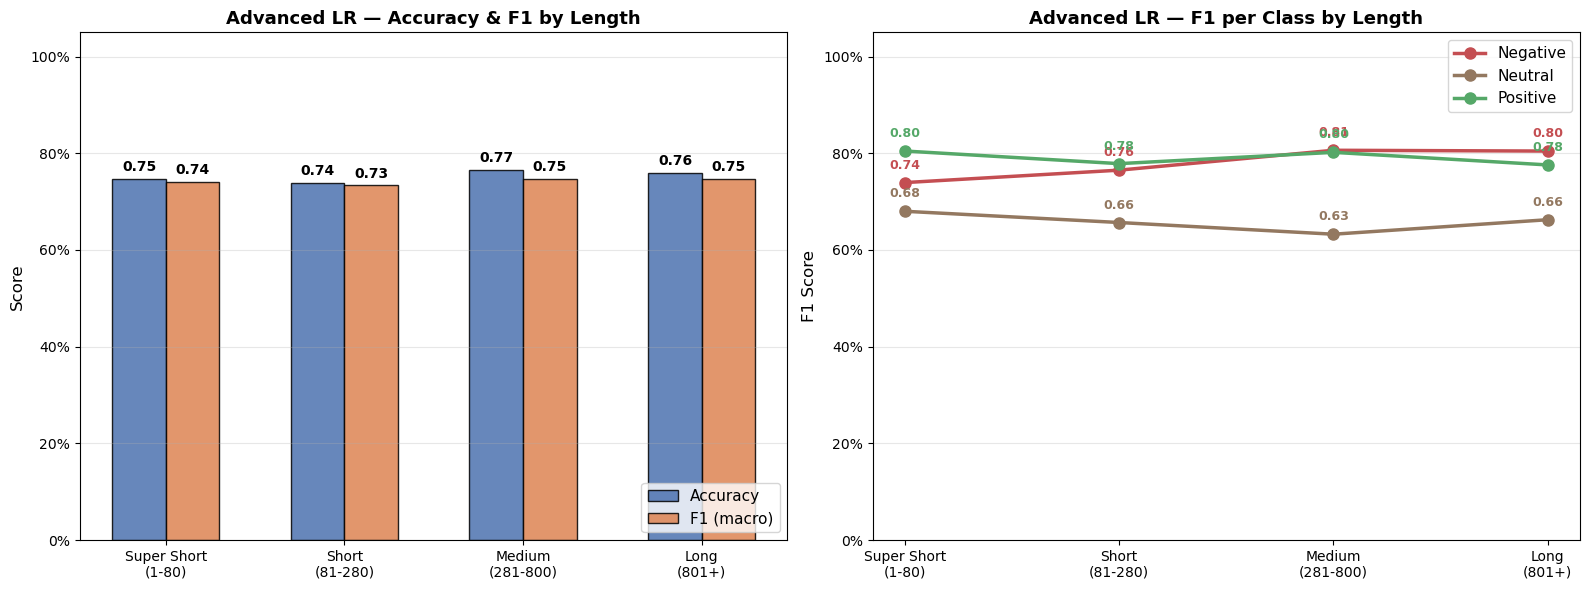

In [14]:
import matplotlib.ticker as mticker

bucket_names = ["super_short", "short", "medium", "long"]
bucket_labels = ["Super Short\n(1-80)", "Short\n(81-280)", "Medium\n(281-800)", "Long\n(801+)"]

accuracies = []
f1_macros = []
f1_per_class = {"negative": [], "neutral": [], "positive": []}

for bucket in bucket_names:
    mask = test_df["bucket"] == bucket
    y_true_b = y_test[mask]
    y_pred_b = y_pred[mask]

    acc = accuracy_score(y_true_b, y_pred_b)
    f1_mac = f1_score(y_true_b, y_pred_b, average="macro", zero_division=0)
    accuracies.append(acc)
    f1_macros.append(f1_mac)

    f1_cls = f1_score(y_true_b, y_pred_b, average=None,
                      labels=["negative", "neutral", "positive"], zero_division=0)
    for j, cls in enumerate(["negative", "neutral", "positive"]):
        f1_per_class[cls].append(f1_cls[j])

    print(f"\n--- {bucket} ({mask.sum()} samples) ---")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  F1 (macro): {f1_mac:.3f}")
    print(f"  F1 per class: neg={f1_per_class['negative'][-1]:.3f}  "
          f"neu={f1_per_class['neutral'][-1]:.3f}  "
          f"pos={f1_per_class['positive'][-1]:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(bucket_names))
width = 0.3

bars1 = ax1.bar(x - width/2, accuracies, width, label="Accuracy",
                color="#4C72B0", edgecolor="black", alpha=0.85)
bars2 = ax1.bar(x + width/2, f1_macros, width, label="F1 (macro)",
                color="#DD8452", edgecolor="black", alpha=0.85)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(bucket_labels, fontsize=10)
ax1.set_ylabel("Score", fontsize=12)
ax1.set_title("Advanced LR: Accuracy & F1 by Length", fontsize=13, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax1.legend(fontsize=11, loc="lower right")
ax1.grid(axis="y", alpha=0.3)

colors = {"negative": "#C44E52", "neutral": "#937860", "positive": "#55A868"}
for cls, color in colors.items():
    ax2.plot(x, f1_per_class[cls], marker="o", markersize=8, linewidth=2.5,
             label=cls.capitalize(), color=color)
    for i, val in enumerate(f1_per_class[cls]):
        ax2.annotate(f"{val:.2f}", (x[i], val), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=9, fontweight="bold", color=color)

ax2.set_xticks(x)
ax2.set_xticklabels(bucket_labels, fontsize=10)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_title("Advanced LR: F1 per Class by Length", fontsize=13, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
class_labels = model.classes_
coef = model.coef_

all_zero_mask = np.all(coef == 0, axis=0)
n_total = len(all_feature_names)
n_dropped = all_zero_mask.sum()
n_kept = n_total - n_dropped

print(f"Total features:   {n_total:,}")
print(f"Kept by L1:       {n_kept:,} ({n_kept/n_total*100:.1f}%)")
print(f"Dropped by L1:    {n_dropped:,} ({n_dropped/n_total*100:.1f}%)")

n_tfidf = len(tfidf_feature_names)
tfidf_dropped_mask = all_zero_mask[:n_tfidf]
eng_dropped_mask = all_zero_mask[n_tfidf:]

print(f"\n--- TF-IDF n-gram features ---")
print(f"  Kept:    {(~tfidf_dropped_mask).sum():,}")
print(f"  Dropped: {tfidf_dropped_mask.sum():,}")

print(f"\n--- Engineered features ---")
for i, fname in enumerate(feature_names_eng):
    status = "DROPPED" if eng_dropped_mask[i] else "KEPT"
    weights = {cl: coef[j, n_tfidf + i] for j, cl in enumerate(class_labels)}
    w_str = ", ".join(f"{cl}: {w:+.4f}" for cl, w in weights.items())
    print(f"  {status:>7s}  |  {fname:<25s}  |  {w_str}")

Total features:   200,011
Kept by L1:       51,993 (26.0%)
Dropped by L1:    148,018 (74.0%)

--- TF-IDF n-gram features ---
  Kept:    51,982
  Dropped: 148,018

--- Engineered features ---
     KEPT  |  pct_uppercase              |  negative: -0.7791, neutral: +0.4061, positive: -0.4255
     KEPT  |  pct_digits                 |  negative: -0.3349, neutral: -0.1133, positive: -0.9813
     KEPT  |  pct_punctuation            |  negative: -0.3951, neutral: -0.1365, positive: +0.4293
     KEPT  |  pct_exclamation            |  negative: -0.2884, neutral: -0.3167, positive: -1.0810
     KEPT  |  pct_question               |  negative: +0.8876, neutral: +1.1499, positive: -0.8167
     KEPT  |  pct_spaces                 |  negative: +1.3077, neutral: -0.2188, positive: +0.5013
     KEPT  |  has_exclamation            |  negative: +0.2299, neutral: -0.2821, positive: +0.5534
     KEPT  |  has_question               |  negative: -0.2349, neutral: -0.5737, positive: -0.8624
     KEPT  |  has

In [16]:
dropped_ngrams = np.array(tfidf_feature_names)[tfidf_dropped_mask]
rng = np.random.RandomState(42)
sample_size = min(50, len(dropped_ngrams))
dropped_sample = rng.choice(dropped_ngrams, size=sample_size, replace=False)

print(f"--- {sample_size} randomly sampled DROPPED n-grams (out of {len(dropped_ngrams):,}) ---")
for i, ng in enumerate(sorted(dropped_sample)):
    print(f"  {ng}")

print("\n")
kept_mask = ~all_zero_mask
kept_indices = np.where(kept_mask)[0]
kept_names = np.array(all_feature_names)[kept_indices]

for j, cl in enumerate(class_labels):
    cl_weights = coef[j, kept_indices]
    top_pos_idx = np.argsort(cl_weights)[-15:][::-1]
    top_neg_idx = np.argsort(cl_weights)[:15]

    print(f"--- Top 15 features FOR '{cl}' ---")
    for idx in top_pos_idx:
        print(f"  {cl_weights[idx]:+.4f}  {kept_names[idx]}")

    print(f"\n--- Top 15 features AGAINST '{cl}' ---")
    for idx in top_neg_idx:
        print(f"  {cl_weights[idx]:+.4f}  {kept_names[idx]}")
    print()

--- 50 randomly sampled DROPPED n-grams (out of 148,018) ---
  baby plz help
  bought bunch
  bruh lmaooo bruh
  buy chips
  carnation instant
  cat developed
  cheap worth
  children black
  coconut milk
  coke br br
  confirmed users
  days dates sleeps
  depression compares
  diamond almonds cinnamon
  direct result
  discovered product
  doesn stand
  enjoy 100
  flavor dog
  food used years
  forgotten
  like classic
  listen brown girls
  little sorry
  look similar
  lot better
  loyalty
  making lot visits
  malic acid propylene
  new gpu drivers
  nice work
  nthe bad
  organic canola
  overall ok
  owner great
  portions good food
  possible acheter
  price think
  recommend eating
  retain nutrients
  schools
  snack love
  speaks br br
  suggestion make
  taste remember
  theater love
  tomato br
  tracing want
  worst enemies
  years born


--- Top 15 features FOR 'negative' ---
  +68.8641  worst
  +58.5988  awful
  +49.4090  horrible
  +46.4697  fix
  +43.5388  waste
  +4